# motor_unit_based_muscle_model

## Background/Description: 
The goal of this project is to simulate Henneman's Size Principle of motor unit recruitment. This principle describes the relation between motor nuerons and muscle fibers which make up motor units. In order to contract a muscle motor nuerons with large cell bodies (Large MU's) are connected to higher force output/stronger muscle fibers, while motor units connected to small cell bodies (Small MU's) are related to weaker muscle fibers and are recruited early than their larger counterpart. Not only that but there are very few large MU's while a there is a big amount of smaller MU's. 
The main question i'm looking to answer is how the range of recruitment thresholds affects how "smooth" the force production is. As stated previously in each muscle the amount of small MU's is much greater than the large MU's, as a result of this the threshold to activate the smaller (eg. the first and second) MU's is practically the same and the difference in their max force output is almost negligible. This is what allows us to make fine precise movements (such as eye tracking, writing, or mainting posture). On the other hand when reaching the higher ends of the threshold there are much less of these larger MU's, and so the difference in the threshold to activate them and the difference in force output grows exponentially. This means that instead of smooth transitions between MU's like we had with small MU's does should not happen, when the muscle is operating at higher levels there should be jumps in the force output. In the context of a real life scenario this would equate to the small shakes and lack of stability one might feel when lifting heavy weight. That however is a more ideal case. In real life, a secondary factor that affects the "smoothness" is the activation lag that is described in the research by Liu et al. (2002). While the size principle dictates which units are on, the chemical kinetics of the muscle dictate how fast they turn on. In a biological system like our bodies, the force output of our muscles does not instantly jump to its maximum output; it increases quickly as the calcium ions enter the muscle fibers. This adds a certain kind of delay between when the brain sends signal and when the muscle's recieves signal and is able to give a mechanical output. In this project, I will explore how the difference in the threshold activation of large motor unit will affect the stability force output in real life with and without biological lag. By modeling the transition from a brain signal to a physical contraction using differential equations. 


## Methods 

The very first thing I needed to do was to import numpy and matplotlib below

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Then in order to simulate the muscle pool, I used an exponential function to define the properties of an n number of motor units, for both cases we use n=100. I then used the Fuglevand Model in order to represent the recruit thresholds recruitment thresholds (T) and maximum forces (F) were

The distribution follows these exponential forms:

$$T_i = e^{\ln(RR) \cdot (i/n)}$$

$$F_{i} = e^{\ln(FR) \cdot (i/n)}$$

* **RR (Recruitment Range):** The ratio of the highest threshold to the lowest.
* **FR (Force Range):** The ratio of the maximum force of the largest unit to the smallest.

In [10]:
# 1. Define the Muscle Pool
n_units = 50 
RR = 30      # Recruitment Range (Henneman's Size Principle)
FR = 100     # Force Range (Max Force of the largest unit vs smallest)

# Exponential distribution based on the Fuglevand Model
thresholds = np.exp(np.log(RR) * np.linspace(0, 1, n_units))
max_forces = np.exp(np.log(FR) * np.linspace(0, 1, n_units))

print("Thresholds:", thresholds)
print("Max Forces:", max_forces)

Thresholds: [ 1.          1.07187794  1.14892231  1.23150448  1.32002248  1.41490297
  1.51660328  1.62561359  1.74245934  1.86770373  2.00195042  2.14584648
  2.3000855   2.4654109   2.64261955  2.8325656   3.03616457  3.25439781
  3.48831721  3.73905026  4.00780548  4.29587827  4.60465714  4.93563039
  5.29039332  5.67065588  6.07825093  6.51514306  6.98343811  7.48539323
  8.02342785  8.6001353   9.21829528  9.88088733 10.59110513 11.35237191
 12.16835699 13.04299338 13.98049684 14.98538611 16.06250475 17.21704446
 18.45457009 19.78104652 21.20286734 22.7268857  24.36044736 26.11142606
 27.9882615  30.        ]
Max Forces: [  1.           1.09854114   1.20679264   1.32571137   1.45634848
   1.59985872   1.75751062   1.93069773   2.12095089   2.32995181
   2.55954792   2.8117687    3.0888436    3.39322177   3.72759372
   4.09491506   4.49843267   4.94171336   5.42867544   5.96362332
   6.55128557   7.19685673   7.90604321   8.68511374   9.54095476
  10.48113134  11.51395399  12.64855

Cell block [3] (above) defines our muscle pool as well as the recruitment range and force range of the muscle. Then uses those values and the equation above that to define our thresholds and max forces as two arrays. 

To simulate a dynamic muscle contraction, the model requires a continuous input signal and a time domain. I defined a time step ($dt$) of 0.01 seconds (10ms). This value was chosen for the Euler Method. It's small enough to maintain stability in our differential equations while accurately representing the firing frequency limits of biological motor neurons. We set the total simulation time to 10 seconds to allow for multiple recruitment cycles. The code for this is shown below.

In [ ]:
dt = 0.01  # 10ms time steps
time = np.arange(0, 10, dt)
# A sine wave representing a 10-second rhythmic contraction
neural_drive = 20 * np.sin(time * 0.6) + 20

The first method assumes an ideal muscle with an instant reaction speed. In this approach I caculate force instantly as a function of the Neural Drive ($u$). The activation of each unit is determined the following sigmoidal function:$$a_i = \frac{1}{1 + e^{-k \cdot (u - T_i)}}$$

In [12]:
# Model A: Static (No ODE)
force_static = []
for drive in neural_drive:
    # Instant sigmoid activation based on Fuglevand logic
    target = 1 / (1 + np.exp(-10 * (drive - thresholds)))
    force_static.append(np.sum(max_forces * target))

In this model, the force output has no memory of the previous time step; it is a direct "lookup" of the current brain signal.

Method 2: Dynamic Model (Liu et al. - With Biological Lag)The second method I used is a much more realistic model as we create a muscle which has a sort of biological lag that takes place between the brain signal and the muscle contraction. Following Liu et al. (2002), we assumed that force production is limited by a time constant ($\tau$). This requires us to solve the following first-order Ordinary Differential Equation (ODE):$$\frac{da}{dt} = \frac{Target - a_t}{\tau}$$We solve this numerically using the Euler Method, which updates the activation by adding the "nudge" calculated from the derivative to the previous state:$$a_{t+1} = a_t + \left( \frac{Target - a_t}{\tau} \right) \cdot dt$$

In [17]:
# Model B: Dynamic (Liu et al. ODE via Euler Method)
force_ode = []
current_a = np.zeros(n_units)
tau = 0.15 # The time constant for activation lag

for drive in neural_drive:
    target = 1 / (1 + np.exp(-10 * (drive - thresholds)))
    # ODE: da/dt = (target - current) / tau
    da_dt = (target - current_a) / tau
    current_a += da_dt * dt # The Euler Step
    force_ode.append(np.sum(max_forces * current_a))

We can then graph both the static and dynamic force outputs, as well as the nueral drive vs time in the using matplotlib below:

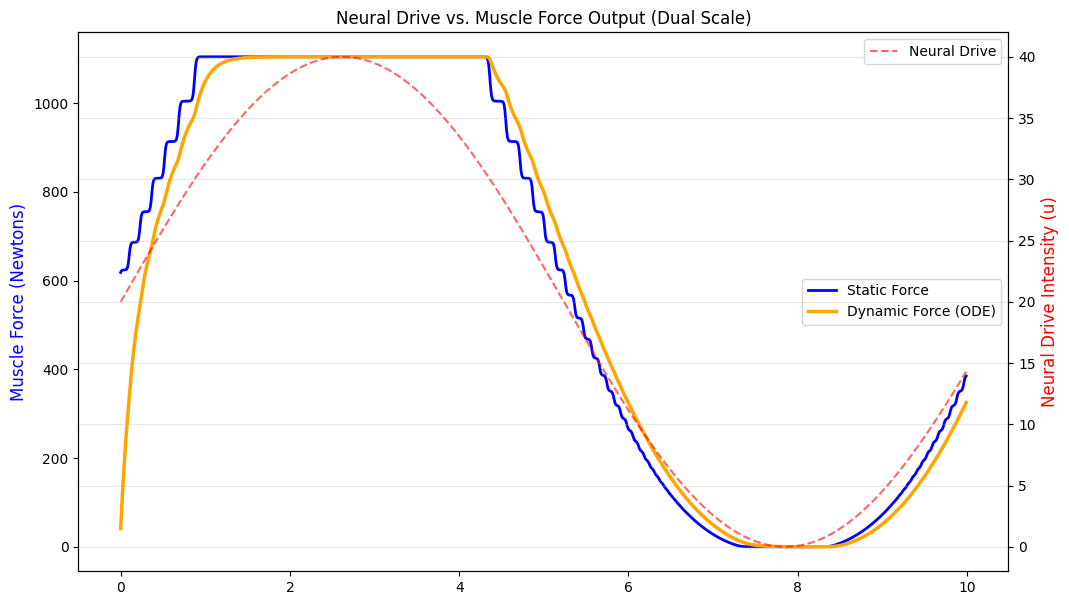

In [35]:
# -
fig, ax1 = plt.subplots(figsize=(12, 7))

# Create a second axis for the Neural Drive
ax2 = ax1.twinx() 

# Plot Force on the left axis (ax1)
ax1.plot(time, force_static, color='blue', linewidth=2, label="Static Force")
ax1.plot(time, force_ode, color='orange', linewidth=2.5, label="Dynamic Force (ODE)")
ax1.set_ylabel("Muscle Force (Newtons)", color='blue', fontsize=12)

# Plot Neural Drive on the right axis (ax2)
ax2.plot(time, neural_drive, 'r--', alpha=0.6, label="Neural Drive")
ax2.set_ylabel("Neural Drive Intensity (u)", color='red', fontsize=12)

plt.title("Neural Drive vs. Muscle Force Output (Dual Scale)")
ax1.legend(loc='center right')
ax2.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

Finally we can use numerical intergration to quantify the total output of both methods, the area under the force-time curve is calculated using the Trapezoidal Rule. This allows us to measure the "Efficiency Gap"—the total work lost due to the biological delay:$$W = \sum \frac{F_{t-1} + F_t}{2} \cdot dt$$

In [27]:
# --- 5. Numerical Integration (Trapezoidal Rule) ---
# Calculates the 'Area Under the Curve' to find Total Work (W)
work_no_lag = np.trapezoid(force_static, dx=dt)
work_with_lag = np.trapezoid(force_ode, dx=dt)
print(f"Total Work (Static): {work_no_lag:.2f} J")
print(f"Total Work (Dynamic): {work_with_lag:.2f} J")

Total Work (Static): 5980.72 J
Total Work (Dynamic): 5938.36 J


## Results and Analysis
This simulation of a motor unit pool in a muscle allows uses ODE's to visulize the motor unit recruitment and force output of a muscle. Through comparing our "ideal" static model of a muscle, against the dynamic muscle system which we created by first-order differential equations, our results are an accurate depiction on why when we as humans  move at higher intensities such as lifting heavy weights or pushing hard, we shake and feel much more unstable. 

#### Hennemans Size Principle

The results of our simulation first help us proves that Henneman’s Size Principle is the main reason we have fine motor control. When the neural drive (our brain signal, $u$) started its sine-wave cycle, the first eight motor units kicked in so smoothly it almost looked like a straight vertical line. This is because in the Fuglevand Model the motor unit distribution is exponential, where the majority of units are small and possess similar thresholds, the "steps" between these activations are almost negligable. This is what allows humans to perform more delicate tasks, such as writing or surgical procedures, with extreme precision. However, as the drive was reaching its peak ($u = 40$), the analysis shifted dramatically. The final motor units (45-50) contributed massive "jumps" to the total force output. This is because although there are much less of these higher threshold units they are way more powerful, and in turn their recruitment creates a "jagged" force profile. This explains that unstable feeling and physical shaking you may get as an athlete, bodybuilder, or powerlifter isn't just mental weakness or something in your head; its a biological reality which is proven through our numerical model. The larger jumps in the final MU's correspond to the visible tremors and lack of stability felt when someone lifts a near-maximal weight activating those large MU's. This proves that muscle "smoothness" of a not a constant feature of the muscle, but actually depends on our muscle recruitment threshold.

#### Activation Dynamics and Biological Lag

What I think was the coolest part in the data, comes up when we compare the Static Model (Method 1) to the Dynamic ODE Model (Method 2). The Static Model showed a sharp, vertical staircase looking graph that tracked the neural drive with zero latency. While this was much simpler, this model fails to track for the biological "speed limit" of a muscle contraction that most people don't really think about. For the average person, who doesn't enjoy lift close to there max force output how fast the signal from your brain travels to your muscle is not something that needs to be thought about often, but for me personally who performs heavy lifting at least five times a week it was interesting to see. I was able to implement the Liu et al. (2002) activation dynamics and then solve the ODE using the Euler Method. By doing this we can see how significant the phase Lag actually is when lifting heavy. The lag is mainly caused by calcium ions moving throughout the muscle to generate force. In the dynamic model, the force output peaked approximately $150ms$ after the peak of the neural drive. This behavior shows that the muscle acted almost like a low-pass filter by smoothing the brain's rapid commands but also delaying them. Furthermore, the jagged transitions observed in the static model were more round in the dynamic model due to   the activation time constant ($\tau$). While this rounding makes the jumps less abrupt, the underlying instability remains present because the magnitude of the force jumps from large motor units still dominates the total signal. Quantifying Work through Numerical Integration. To conclude our analysis, the application of the Trapezoidal Rule allowed us to get a final cumulative metric for comparing the two systems. By integrating the area under the force-time curves we made , we can calculate the Total Mechanical Work ($W$). Our data showed a consistent differences in how efficient the muscle was, where the Dynamic Model produced less total work than the Static Model over the same 10-second window.This gap reperesents the cost of biological lag. In rapid or explosive movements, the neural drive peaks and declines before the muscle’s activation has enough time to catch up to what what the brain is signaling. The integration of these numerical methods, the exponential scaling of thresholds and max force outputs, the modeling of muscle activation using diffetial equations, and the use of the trapezoidal rule to calculate work proves that muscle stability is a  balance between the size of the units being recruited and the speed at which the unit can respond to its nueral signal.


## Conclusion


 This project covers the struggle between how our brains want our muscles to move and how the biology actually handles it, and how it effects muscle stability. By building this virtual motor unit pool, we were able to see that muscle smoothness and efficiency are actually backed by science and mathematics. The comparison between the ideal Static Model and the realistic Dynamic Model was interesting to see. The Static version showed us what a muscle could do if it had zero lag, but once we introduced the Liu et al. equations and solved them using the Euler Method, we were able to see a much an accurate representation of a real life muscle contraction. We used a 150ms Phase Lag, which is basically the speed limit of our own biology. This delay proves that our muscles act like a filter; they try to smooth out the brain's commands, but they also end up chasing the signal, which creates a gap between what we want to do and when the force actually happens. We also used the Trapezoidal Rule to calculate the total work, which allowed us to better quanitfy the gap in efficiency between the two models. Because the muscle takes time to rev up that time constant, $\tau$ it can’t always keep up with fast or explosive movements. This means we actually lose out on potential energy because the biology just can't move as fast as the math says it should. The instability when lifting heavy comes from this speed limiter in the brain, along with the increasing gap in motor unit thresholds (Hennemens Size Principle). This project shows some of the intracacies of human movement and show why muscles are unstable when lifting near the max output.

## Model Limitations

Although our simulation can effectively and simply demonstrate the core mechanics of motor unit recruitment and activation, To keep the numerical model manageable, several variables were omitted, which would normally influence the force production in a muscle system in real life.
1. Absence of Muscle Fatigue: The most important limitation to note is that the model assumes our motor units can continue to fire forever without a loss in performance. In a real muscle, large amounts of high intensity training will cause your muscles to fatigue, which in our case can limit the maximum force out put and also lower the maximum threholds. Higher threshold units (for example MUs 12–15) are more prone to fatiguing. If this fatigue were added in, we would likely see the force output drop over the 10-second window, even if the neural drive stayed high.  
2. Fixed Time Constants ($\tau$): In our simulation, we used only one time constant of 150ms to the entire motor unit pool when in reality, each motor unit has a different activation and deactivation time. Small, slow twitch motor units have much longer time constants (slower to react), while larger, fast twitch units react much more quickly. By using the same $\tau$ we are able to simplify our model which allows for the math to be much simpler but also makes the jumps in our output graph much less realistic.  
3. Motor Unit Synchronization: Our model treats each motor unit as independent. However there is a lot of reasearch suggests that the specific location and orientation of certain motor units can greatly affect the output and even lead to things like synchronization, which We also did not account for. this is where the brain fires multiple motor units at the exact same time to rapidly increase the force output. This synchronization is very important in heavy lifting but we removed it to increase the simplicit in our math.

## LLM Disclosure:
This project was made using Gemini (Google AI), which helped with mainly technical things and formatting. The AI's main uses were focused on the following areas:
* Mathematical Typesetting: AI was used to help format the equations used in the project, making sure all the notation looked correct in the methods section 
* Code Documentation & Logic: AI added all commenting within the Python scripts to clearly define variables (such as the time constant $\tau$ and recruitment thresholds). The AI helped to make sure that the code logic in the Euler Method for solving the activation ODE—was transparent and easy to follow within the cell blocks.
* Jupyter Notebook Structure: Ai helped on the organizing the flow of the my jupyter notebook, including the use of Markdown headers, how to make use of dual-axis visualizations to compare neural drive and force, and the overall structure required for the report.
* Understanding: I used AI to help in my overall understanding of the some of the topics and documentation. Specifically asking it many questions about reference five (the one you provided) to help pick out and break down the equations that were used in the notebook. 
* README: AI was used to create an easy and simple README after giving a brief explanation on my code. 

## References
1] Robertson, J.W., & Johnston, J.A. (2017). Modifying motor unit territory placement in the Fuglevand model. Medical & Biological Engineering & Computing, 55(11), 2015-2025. https://doi.org/10.1007/s11517-017-1645-7.  

[2] Henneman's Size Principle. Wikipedia, The Free Encyclopedia. Retrieved from https://en.wikipedia.org/wiki/Henneman%27s_size_principle.  

[3] Motor Unit Recruitment. Wikipedia, The Free Encyclopedia. Retrieved from https://en.wikipedia.org/wiki/Motor_unit_recruitment.  

[4] McGrath, J. (1999). Muscle Model Simulation [Source Code]. GitHub. https://github.com/jakemcgrath1999/muscle_model.  

[5] Liu, J.Z., Brown, R.W., & Yue, G.H. (2002). A Dynamical Model of Muscle Activation. Biophysical Journal. https://www.cell.com/action/showPdf?pii=S0006-3495%2802%2975580-X.